### **FINANCIAL INCLUSION IN EAST AFRICA**

---

**Problem Statement**

Financial inclusion remains a key challenge across East Africa, where access to formal banking services is uneven across different demographic and socioeconomic groups.

Understanding who is more likely to own or use a bank account can help inform policies, improve financial access, and guide digital banking solutions.


**Objective**

This project aims to:
- Identify the key factors influencing financial inclusion
- Explore patterns across countries, demographics, and socioeconomic variables
- Build a machine learning model to predict the likelihood of an individual having a bank account

---

**Dataset Overview**

The dataset contains demographic and socioeconomic information for approximately 23,500 individuals across East Africa.

The data covers four countries:
- Kenya
- Uganda
- Tanzania
- Rwanda

and spans the period **2016 to 2018**.

---

**Target Variable**

- `bank_account`: Indicates whether an individual has or uses a bank account (Yes/No)

---

**Features**

The dataset includes a mix of:

- **Demographic factors**
  - Age of respondent  
  - Gender  
  - Relationship with household head  

- **Socioeconomic factors**
  - Education level  
  - Job type  
  - Marital status  
  - Household size  

- **Access and location factors**
  - Country  
  - Location type (Urban/Rural)  
  - Cellphone access  

---

**Relevance**

These features capture key aspects that influence financial inclusion, such as economic activity, education, and access to communication infrastructure.

In [1]:
# import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from ydata_profiling import ProfileReport


c:\Users\Crystal\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load the dataset
df = pd.read_csv("Financial_inclusion_dataset.csv")
df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


---

**Data Cleaning**

Before proceeding with analysis, the dataset was checked for consistency and quality.

---

**Structure and Data Types**

- The dataset contains **13 columns and 23,524 rows**
- Data types are appropriate for analysis, with a mix of categorical and numerical variables


**Missing Values**

- No missing values were found across all columns


**Duplicates**

- No duplicate records were identified in the dataset

---

**Summary**

- The `uniqueid` column is an identifier and will not be used for modeling. 
- The dataset is clean and requires minimal preprocessing before analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


- `13 columns`
- `23,524 rows`

In [4]:
# profile report
profile = ProfileReport(df, title="Financial Inclusion In Africa")
profile.to_file("financial_inclusion.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 162.30it/s]


In [5]:
# handle null values
df.isnull().sum()

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

- `0 nulls`

In [6]:
# handle duplicates
df.duplicated().sum()

np.int64(0)

- `0 duplicates`

In [7]:
# unique values in country column
print(df['country'].unique())
print(df['year'].unique())

['Kenya' 'Rwanda' 'Tanzania' 'Uganda']
[2018 2016 2017]


---

**Key Questions**

To guide the analysis, the following questions are explored:

- Which demographic groups are more likely to have a bank account?
- How does education level influence financial inclusion?
- Does access to a mobile phone affect the likelihood of having a bank account?
- Are there differences in financial inclusion across countries?
- What is the gap between urban and rural populations in access to banking services?

---
**EDA**

---


**1. Distribution of Bank Account Ownership**

*-- Target Distribution*

In [8]:
df['bank_account'].value_counts(normalize=True) * 100

bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64

- The dataset is highly imbalanced, with a small proportion of individuals having bank accounts, which may affect model performance.

*-- Bank Account Distribution YoY(%)*

C:\Users\Crystal\AppData\Local\Temp\ipykernel_28192\3247120550.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['year', 'bank_account']).size().unstack()


Bank Account Distribution by Year:
bank_account    No   Yes
year                    
2016          7732  1003
2017          6013   607
2018          6467  1702


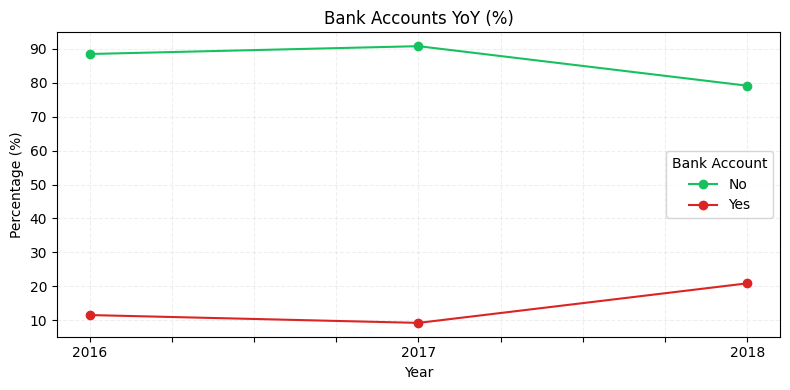

In [9]:
# Count bank accounts by year
# cross-tabulation
cross_tab = pd.crosstab(df['year'], df['bank_account'])
print("Bank Account Distribution by Year:")
print(cross_tab)

# Convert 'year' to categorical for better plotting(without the resulting chart is sorted by quarter
# instead of year)
df['year'] = df['year'].astype('category')

# percentage
counts = df.groupby(['year', 'bank_account']).size().unstack()
counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100

# plot
ax = counts_pct.plot(marker='o', figsize=(8,4), color=["#18c15f", "#dc2424"])

plt.title("Bank Accounts YoY (%)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend(title="Bank Account")

ax.grid(axis='both', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

- Over the years, there is an increase in the number of people who have a bank account. However, the count of individuals without is still relatively high in comparison.

---

**2. Financial Inclusion by Country**

In [10]:
# Count occurrences
counts = df['country'].value_counts()

# Convert to percentages
percentages = (counts / counts.sum()) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage(%)': percentages
})
print(result.round(2))

          Count  Percentage(%)
country                       
Rwanda     8735          37.13
Tanzania   6620          28.14
Kenya      6068          25.79
Uganda     2101           8.93


- `Uganda accounts for only ~9%` of the dataset, significantly underrepresented compared to `Rwanda (37%)`, `Tanzania (28%)`, and `Kenya (26%)`, which may skew regional insights toward countries with higher sample sizes


--
*Bank Account Percentage Distribution By Country*


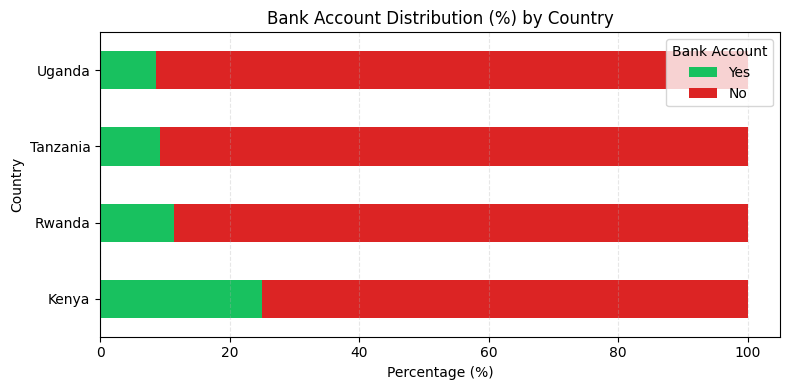

In [11]:
# Bank account distribution by country

df['bank_account'] = pd.Categorical(df['bank_account'], categories=['Yes', 'No'], ordered=True)

# Cross-tabulation
ct = pd.crosstab(df['country'], df['bank_account'])

# Calculate percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100


# Plot
ax = ct_pct.plot(kind='barh', stacked=True, figsize=(8, 4), color=["#18c15f", "#dc2424"])

plt.title('Bank Account Distribution (%) by Country')
plt.xlabel('Percentage (%)')
plt.ylabel('Country')
plt.legend(title='Bank Account', loc='upper right')

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Kenya shows a relatively higher rate of bank account ownership (~23%) compared to other countries, while Uganda, despite being underrepresented in the dataset, demonstrates comparable inclusion levels.

---

**3. Urban vs Rural Analysis**


*-- Bank Account Distribution (%) by Location Type*

Bank Account Distribution by Location:
bank_account    Yes     No
location_type             
Rural          1671  12672
Urban          1641   7540


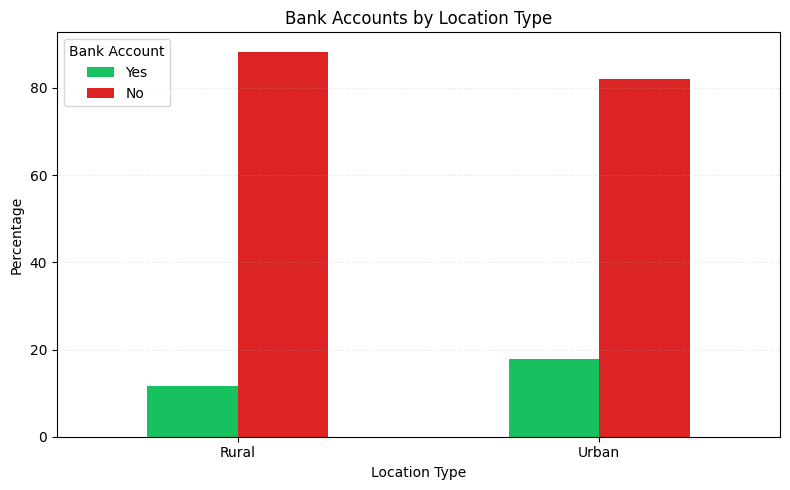

In [12]:
# location vs bank account
location_crosstab = pd.crosstab(df['location_type'], df['bank_account'])
print("Bank Account Distribution by Location:")
print(location_crosstab)

lcp = location_crosstab.div(location_crosstab.sum(axis=1), axis=0) * 100

ax = lcp.plot(kind='bar', figsize=(8, 5), color=["#18c15f", "#dc2424"])

plt.title("Bank Accounts by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Percentage")
plt.legend(title="Bank Account")
plt.xticks(rotation=0)

ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

- Bank account ownership is higher in urban areas (~18%) compared to rural areas (~12%). Despite this, the majority of individuals in both locations remain unbanked, with rural areas showing the lowest levels of financial inclusion.

---

**4. Demographic Factors**


*-- Bank Account Distribution (%) by Age Group*

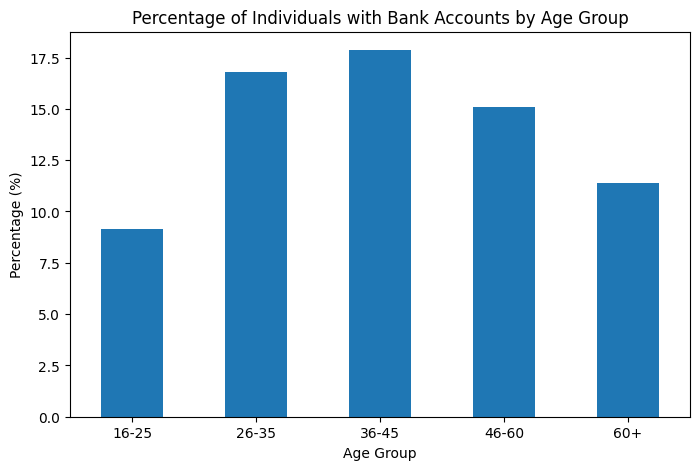

In [13]:
# Create age groups
bins = [16, 25, 35, 45, 60, 100]
labels = ['16-25', '26-35', '36-45', '46-60', '60+']

df['age_group'] = pd.cut(df['age_of_respondent'], bins=bins, labels=labels)

# Ensure correct order
df['age_group'] = pd.Categorical(df['age_group'], categories=labels, ordered=True)

# Compute percentage of bank account ownership within each age group
age_pct = pd.crosstab(df['age_group'], df['bank_account'], normalize='index') * 100

# Plot ONLY percentage of "Yes"
age_yes_pct = age_pct['Yes']

age_yes_pct.plot(kind='bar', figsize=(8,5))
plt.title("Percentage of Individuals with Bank Accounts by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

- The likelihood of having a bank account increases with age, with younger individuals showing the lowest financial inclusion rates.


*-- Bank Account Distribution (%) by Education Level*

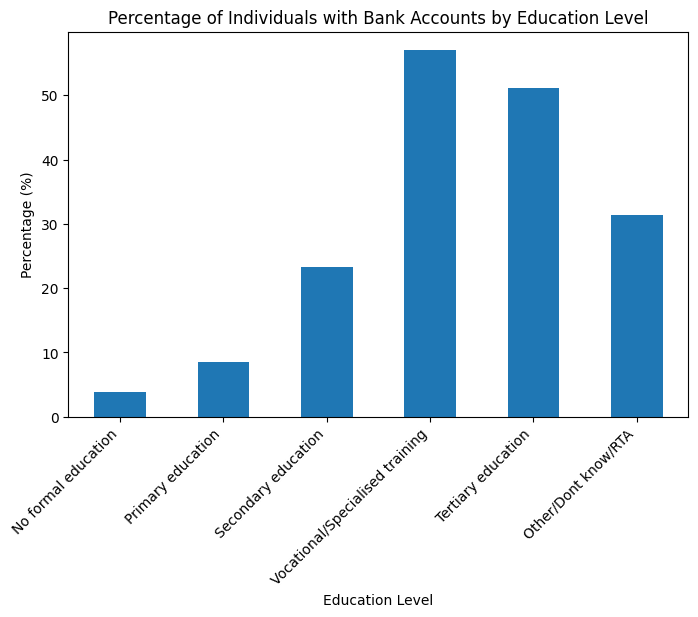

In [14]:
# bank account distribution by education level

# Ensure education levels are ordered meaningfully
edu_order = [
    "No formal education",
    "Primary education",
    "Secondary education",
    "Vocational/Specialised training",
    "Tertiary education",
    "Other/Dont know/RTA"
]

df['education_level'] = pd.Categorical(df['education_level'], categories=edu_order, ordered=True)

# Compute percentage of bank account ownership within each education level
edu_pct = pd.crosstab(df['education_level'], df['bank_account'], normalize='index') * 100

# Plot ONLY percentage of "Yes"
edu_yes_pct = edu_pct['Yes']

edu_yes_pct.plot(kind='bar', figsize=(8,5))
plt.title("Percentage of Individuals with Bank Accounts by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha='right')
plt.show()

- Financial inclusion increases with education level, with individuals having secondary and tertiary education significantly more likely to own a bank account.


*-- Bank Account Distribution (%) by Gender*

Bank Account Distribution by Gender:
bank_account           Yes     No
gender_of_respondent             
Female                1482  12395
Male                  1830   7817


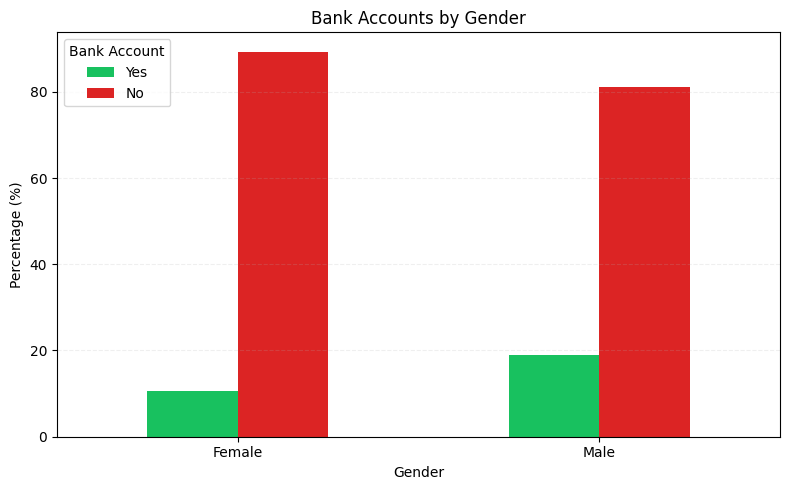

In [15]:
# Gender vs bank account
gender_crosstab = pd.crosstab(df['gender_of_respondent'], df['bank_account'])
print("Bank Account Distribution by Gender:")
print(gender_crosstab)

gcp = gender_crosstab.div(gender_crosstab.sum(axis=1), axis=0) * 100

#plot
ax = gcp.plot(kind='bar', figsize=(8, 5), color=["#18c15f", "#dc2424"])

plt.title("Bank Accounts by Gender")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.ylabel("Percentage (%)")
plt.legend(title="Bank Account")

ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

- Although females make up a larger proportion of the dataset, males exhibit a higher bank account ownership rate (19% vs 11%). This suggests a clear gender disparity in financial inclusion, with women being nearly half as likely to have a bank account as men.

---

**5. Socioeconomic Factors**


*-- Cellphone Access vs Bank Account Ownership by Country (%)*

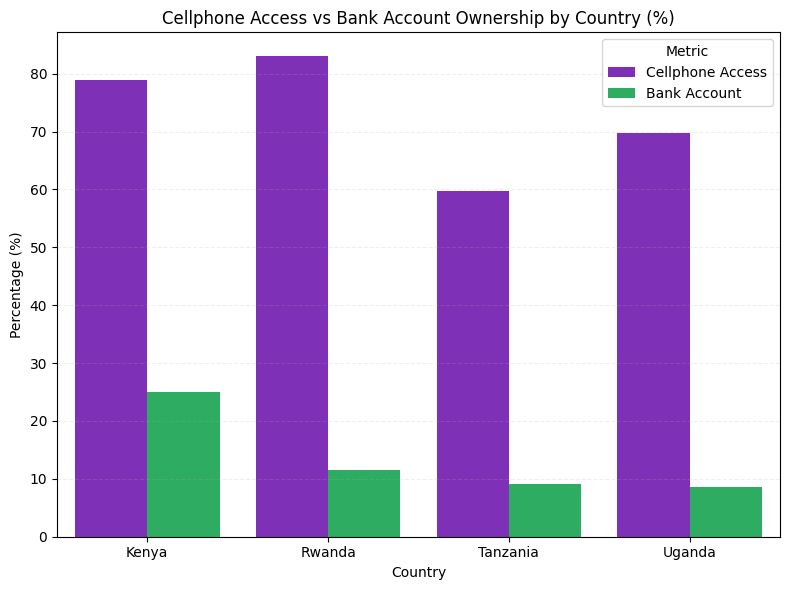

In [16]:
# Cellphone Access vs Bank Account Ownership by Country (%)

# Crosstabs 
cellphone_crosstab = pd.crosstab(df['country'], df['cellphone_access'])
bank_crosstab = pd.crosstab(df['country'], df['bank_account'])

# Ensure column order is consistent
cellphone_crosstab = cellphone_crosstab[['Yes', 'No']]
bank_crosstab = bank_crosstab[['Yes', 'No']]

# Convert to %
cellphone_pct = cellphone_crosstab.div(cellphone_crosstab.sum(axis=1), axis=0) * 100
bank_pct = bank_crosstab.div(bank_crosstab.sum(axis=1), axis=0) * 100

# Extract "Yes" percentages and reset index
cellphone_yes = cellphone_pct['Yes'].reset_index(name='cellphone_pct')
bank_yes = bank_pct['Yes'].reset_index(name='bank_pct')

# Merge
comparison = pd.merge(cellphone_yes, bank_yes, on='country')

# Reshape
comparison_melted = comparison.melt(
    id_vars='country',
    value_vars=['cellphone_pct', 'bank_pct'],
    var_name='Type',
    value_name='Percentage'
)

comparison_melted['Type'] = comparison_melted['Type'].replace({
    'cellphone_pct': 'Cellphone Access',
    'bank_pct': 'Bank Account'
})

# Plot
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=comparison_melted,
    x='country',
    y='Percentage',
    hue='Type',
    palette=["#8219cd", "#18c15f"]
)

plt.title('Cellphone Access vs Bank Account Ownership by Country (%)')
plt.xlabel('Country')
plt.ylabel('Percentage (%)')

plt.legend(title='Metric', loc="upper right")
ax.grid(axis='y', linestyle='--', alpha=0.2)    

plt.tight_layout()
plt.show()

- *Cellphone access* is high across all countries *(60–83%)*, but *bank account ownership* remains much lower *(9–25%)*. 
Kenya has the highest banking rate, while Rwanda shows the largest gap between access and inclusion. This suggests that *widespread mobile access does not necessarily translate into financial inclusion*.

---

**FEATURE ENGINEERING**

---

To prepare the data for modeling, categorical and numerical features were transformed into a suitable format.

**Encoding**

- Binary variables such as `cellphone_access` and `gender_of_respondent` were label encoded  
- Ordinal relationships in `education_level` were preserved through mapping  
- Nominal variables such as `country`, `location_type`, `marital_status`, `relationship_with_head`, and `job_type` were one-hot encoded  


**Feature Selection**

- The `uniqueid` column was removed as it does not contribute to prediction  

---

**Final Dataset**

- All features were combined into a structured format suitable for machine learning models  
- Feature ordering was aligned to match the training pipeline

---

*-- Handle outliers*

- Outliers in numerical features were handled using the IQR method.  
- Lower bounds were constrained using domain knowledge to ensure realistic values.

In [17]:
# handle outliers
# Define numerical columns with their minimum allowed values
num_cols = {
    'age_of_respondent': 18, # minimum age to have a bank account
    'household_size': 1 # minimum number of people in a household
}


def clip_outliers(df, num_cols):
    for col, min_val in num_cols.items():
        # Calculate IQR bounds
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Calculate bounds with minimum enforcement
        lower = max(Q1 - 1.5 * IQR, min_val)  # Ensures minimum value
        upper = Q3 + 1.5 * IQR
        
        # Count outliers (values outside bounds)
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        
        # Print stats
        print(f"Number of outliers: {n_outliers}")
        
        # Clip values to enforced bounds
        df[col] = df[col].clip(lower=lower, upper=upper)
    
    return df

# Apply to dataframe
df_clean = clip_outliers(df.copy(), num_cols)


# Show final statistics
print("\nFinal statistics after clipping:")
print(df[list(num_cols.keys())].describe())

Number of outliers: 1180
Number of outliers: 381

Final statistics after clipping:
       age_of_respondent  household_size
count       23524.000000    23524.000000
mean           38.805220        3.797483
std            16.520569        2.227613
min            16.000000        1.000000
25%            26.000000        2.000000
50%            35.000000        3.000000
75%            49.000000        5.000000
max           100.000000       21.000000


*-- Feature Selection*

- The `uniqueid` column was removed as it is an identifier and does not contribute to prediction
- The derived column `age_group` is not needed for modeling

In [18]:
df_clean.drop(columns='uniqueid', inplace=True)

df_clean = df_clean.drop(columns=['age_group'], errors='ignore')

*-- Feature Encoding*

Categorical variables were transformed into numerical representations to make them suitable for machine learning models.

---

*Encoding Approach*

- Binary variables (`cellphone_access`, `gender_of_respondent`) were label encoded  
- Nominal variables (`country`, `location_type`, `relationship_with_head`, `marital_status`, `job_type`) were one-hot encoded  
- Ordinal relationships in `education_level` were preserved through manual mapping  

---

- All features were combined into a structured dataset ready for model training

In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df_model = df_clean.copy()

#-----------------------------------------------------------------#

# Binary Columns
binary_cols = ['cellphone_access', 'gender_of_respondent']

label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

#-----------------------------------------------------------------#

# Nominal Columns
nominal_cols = [
    'country', 
    'location_type', 
    'relationship_with_head', 
    'marital_status', 
    'job_type'
]

# OneHot Encoding
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform the nominal columns
encoded_nominal = onehot_encoder.fit_transform(df_model[nominal_cols])

encoded_df = pd.DataFrame(
    encoded_nominal,
    columns=onehot_encoder.get_feature_names_out(nominal_cols),
    index=df_model.index # Ensure the new DataFrame has the same index as df_model for proper concatenation
)

# Drop original nominal columns and concatenate the new one-hot encoded columns
df_model = df_model.drop(columns=nominal_cols)
df_model = pd.concat([df_model, encoded_df], axis=1)

#-----------------------------------------------------------------#

# Ordinal Encoding
education_order = {
    'No formal education': 0,
    'Primary education': 1,
    'Secondary education': 2,
    'Vocational/Specialised training': 3,
    'Tertiary education': 4,
    'Other/Dont know/RTA': 0
}

df_model['education_level'] = df_model['education_level'].map(education_order)

df_model['education_level'] = df_model['education_level'].fillna(0)

#-----------------------------------------------------------------#

print("Encoding complete. Shape:", df_model.shape)

Encoding complete. Shape: (23524, 29)


---

**MODELING & EVALUATION**

---

A machine learning model was developed to predict the likelihood of an individual having a bank account based on demographic and socioeconomic features.


**Train-Test Split**

- The dataset was split into training and testing sets to evaluate model performance on unseen data


**Model Selection**

- A Random Forest classification model was used to predict bank account ownership (Yes/No)
- Random Forest was selected for its ability to capture non-linear relationships and handle categorical features effectively


**Evaluation Metric**

- Accuracy and classification metrics were used to assess model performance


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Convert target variable to binary
df_model['bank_account'] = df_model['bank_account'].map({'Yes': 1, 'No': 0})

# define features and target variable
X = df_model.drop('bank_account', axis=1)
y = df_model['bank_account']

*-- Train-Test Split*

- The dataset was split into training and testing sets  
- Stratification was applied to preserve the class distribution of the target variable

In [21]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

*-- Handle Class Imbalance*

- The dataset is imbalanced, with fewer individuals having bank accounts  
- SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data to balance the classes  
- Oversampling was performed only on the training set to avoid data leakage

In [23]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to oversample the minority class in the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())


Before SMOTE: bank_account
0    16169
1     2650
Name: count, dtype: int64
After SMOTE:
 bank_account
1    16169
0    16169
Name: count, dtype: int64


*-- Model Training*

- A Random Forest classifier was trained on the resampled training data  
- The model is used to capture non-linear relationships between features and the target variable

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


*-- Model Evaluation*

- The model was evaluated on the test set using accuracy and classification metrics  
- Additional metrics were used to assess performance on the minority class

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8580

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      4043
           1       0.50      0.46      0.48       662

    accuracy                           0.86      4705
   macro avg       0.70      0.69      0.70      4705
weighted avg       0.85      0.86      0.86      4705


Confusion Matrix:

[[3733  310]
 [ 358  304]]


- While the model achieves high overall accuracy, performance on the minority class (individuals with bank accounts) is lower, reflecting the impact of class imbalance

*-- Hyperparameter Tuning*

- Randomized Search was used to identify optimal model parameters  
- Cross-validation was applied to improve model generalization  
- Tuning was performed on the resampled training data

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define model and parameter distribution
model = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# RandomizedSearchCV for efficient hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,          # Number of parameter combinations to try
    cv=5,               # 5-fold cross-validation
    n_jobs=-1,          # Use all available processors
    random_state=42
)

# Fit the model
random_search.fit(X_train_res, y_train_res)

# Get the best parameters and score
best_params = random_search.best_params_
best_score = random_search.best_score_

# Display the results
print("Best parameters:", best_params)
print("Best score:", best_score)


Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 30}
Best score: 0.9114379324975982


In [36]:
# Use the best model
best_model = random_search.best_estimator_

# Evaluate
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      4043
           1       0.53      0.45      0.49       662

    accuracy                           0.87      4705
   macro avg       0.72      0.69      0.71      4705
weighted avg       0.86      0.87      0.86      4705



*-- Tuned Model Evaluation*

- The tuned model was evaluated on the original test set to assess real-world performance  
- While cross-validation showed improved performance, results on the test set provide a more reliable measure due to the original class imbalance  

*-- Save model*

In [37]:
# Save for Streamlit
import joblib

joblib.dump({
    'label_encoders': label_encoders,      # For binary columns
    'onehot_encoder': onehot_encoder,      # For nominal features
    'education_mapping': education_order,  # For education levels
    'feature_names': df_model.drop('bank_account', axis=1).columns.tolist()    # For feature order validation
}, 'preprocessing_artifacts.pkl')


# Save trained model
joblib.dump(best_model, 'model.pkl')

['model.pkl']

---

**Conclusion**

This project explored financial inclusion across East Africa using demographic and socioeconomic data.

---

**Key Findings**

- Financial inclusion is strongly influenced by education level, age, and access to a mobile phone  
- Urban populations show higher levels of bank account ownership compared to rural populations  
- Significant class imbalance exists, with a majority of individuals not having bank accounts  

---

**Model Performance**

- A Random Forest classifier was trained to predict bank account ownership  
- SMOTE was applied to address class imbalance during training  
- Hyperparameter tuning improved model performance during cross-validation  
- Evaluation on the test set showed that overall accuracy is high, but performance on the minority class remains more challenging  

---

**Implications**

- Access to education and digital infrastructure plays a key role in improving financial inclusion  
- Targeted interventions may be needed for underrepresented and underserved populations  

---

**Future Work**

- Explore additional models and ensemble methods
- Improve performance on the minority class through advanced imbalance handling techniques  